# DPO — does detrending the price reveal a cycle you can trade?
### The Detrended Price Oscillator's overbought/oversold cycle rule, tested honestly on real tapes

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Isolates a tradable cycle%3F: Busted](https://img.shields.io/badge/Isolates_a_tradable_cycle%3F-Busted-8b949e?style=flat-square)

Here's a recipe you'll meet on every charting platform: subtract a moving average from the price to *remove the trend*, and what's left — the **Detrended Price Oscillator** — supposedly exposes the market's hidden short-term **cycle**. Buy at the cycle low, sell at the cycle high. The pitch is seductive: strip out the boring trend and trade the rhythm underneath. Does the rhythm exist — and can you trade it?

> This is the plain-language layer. Want the HAC *t*-stats, the permutation placebo, the cost sweep and the look-ahead trap? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from detrended_price_oscillator import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "EFA", "GLD", "DBC"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))
AS_OF = "2026-05-31"

def _have(t):
    return os.path.exists(data._cache_path(t, CACHE))

HAVE_REAL = all(_have(t) for t in TICKERS)
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the DPO rule beat buy-and-hold? | **No.** On SPY (1993–2026) the long/flat DPO rule earns a net **+0.43** Sharpe vs buy-and-hold's **+0.65** — it *gives up* 5.5%/yr. |
| Is the underperformance real? | Yes — HAC *t* on the daily excess gap = **-3.11**. But that just measures the cost of sitting in cash 63% of the time during a bull market. |
| Does it work on *anything*? | No: every tape in the basket (stocks, small-caps, foreign, gold, commodities) underperforms its own buy-and-hold. |
| Could you trade it? | **No.** The rule is a structural loser before costs; costs just deepen the hole. |

> The DPO does remove the trend — that's exactly the problem. In a market that mostly *trends up*, detrending and trading the residual is a machine for **being out of the trend**.

## 1 · The claim

> *"Subtract an n-day moving average from the price and you remove the trend. What remains is the market's short-term **cycle**. When the DPO dips to a trough the asset is at a cycle low — buy. When it peaks the asset is at a cycle high — sell. Detrending isolates a tradable rhythm that a plain moving average hides."*

The DPO is a staple of charting textbooks (Achelis, *Technical Analysis from A to Z*). Its selling point over a moving average is precisely that it *strips the trend out* so the cycle stands naked. We test whether that cycle is real and whether trading it beats just holding.

## 2 · So what?

If detrending really surfaced a tradable cycle, it would be a mechanical timing edge anyone could run with one line of pandas. Millions of retail traders apply DPO and its cousins daily. But there is a deep tension in the premise: the long-run equity return *is* the trend. A rule whose whole design is to ignore the trend is, by construction, fighting the one force that has actually paid investors. If the 'cycle' is mostly noise, following DPO means paying costs to sit out the very uptrend you were trying to harvest.

## 3 · How would we know?

One honest test:

1. **Turn the DPO into a real position.** Long when the (look-ahead-free) DPO is below its lower band, flat when above the upper band. Hold the position with a one-day execution lag.
2. **Race it against buy-and-hold**, both measured *excess of cash*, net of costs. If the cycle is real and tradable, the DPO rule's Sharpe should *beat* simply holding.
3. **Shuffle the timing.** Randomly slide the position series in time thousands of times. If DPO's *timing* carries information, the real result should sit in the tail.
4. **Compare to the obvious benchmarks** (an SMA crossover, MACD) so 'DPO is better' is actually tested.

**What would make us say 'mirage':** the DPO rule fails to beat buy-and-hold, the timing shuffle can't tell the real run from random, and it's no better than a plain SMA. We run it on six tapes (SPY, QQQ, IWM, EFA, GLD, DBC) over their full Yahoo histories.

## 4 · The teardown — what actually happens

**First, the headline race on SPY: DPO timing vs simply holding.**

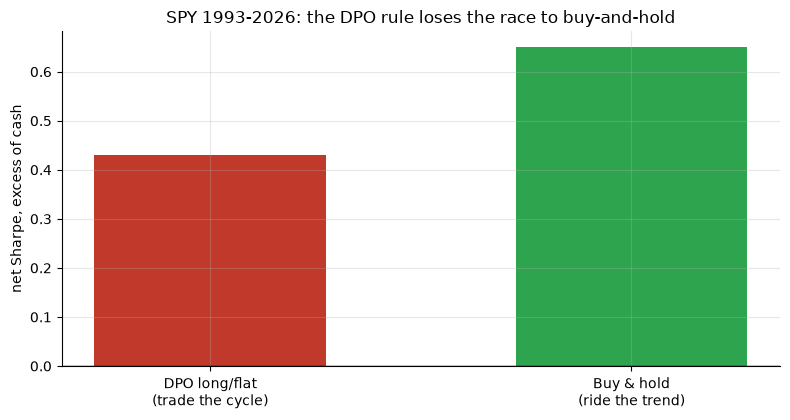

DPO net Sharpe +0.43  vs  buy-and-hold +0.65


In [2]:
if HAVE_REAL:
    b = data.load_real('SPY', cache_dir=CACHE, end=AS_OF)
    s = st.run_experiment(b['close'], period=20, band_k=1.0, cost_bps=1.0, n_perm=2000)
    strat_sh, mkt_sh = s['strat_sharpe'], s['mkt_sharpe']
else:
    strat_sh, mkt_sh = 0.43, 0.65
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['DPO long/flat\n(trade the cycle)', 'Buy & hold\n(ride the trend)'],
       [strat_sh, mkt_sh], color=[RED, GREEN], width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net Sharpe, excess of cash')
ax.set_title('SPY 1993-2026: the DPO rule loses the race to buy-and-hold')
plt.tight_layout(); plt.show()
print(f'DPO net Sharpe {strat_sh:+.2f}  vs  buy-and-hold {mkt_sh:+.2f}')

The DPO rule nets a **+0.43** Sharpe; buy-and-hold delivers **+0.65**. The rule *underperforms by 5.5%/yr*. And the gap is statistically solid (HAC *t* on the daily difference = **-3.11**) — but in the *wrong* direction: it reliably measures the cost of sitting out the trend, not a reversal edge.

**Does it fail everywhere, or is SPY special?**

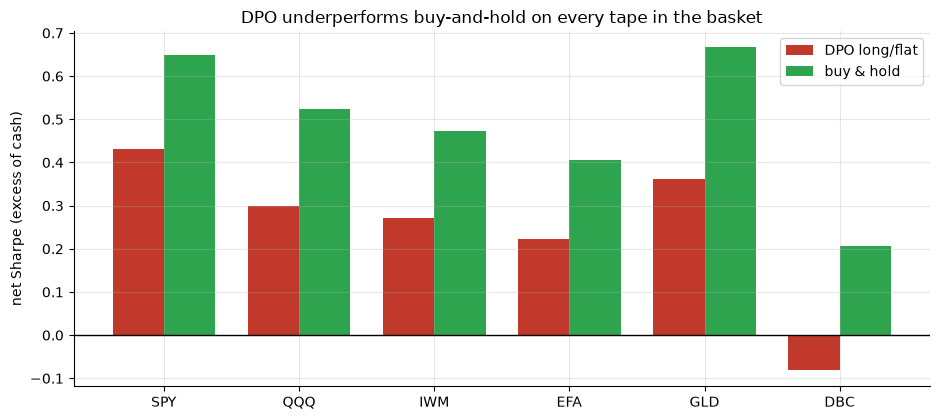

,ticker,DPO_Sh,BH_Sh,delta
0,SPY,0.43,0.65,-0.22
1,QQQ,0.30,0.52,-0.22
2,IWM,0.27,0.47,-0.20
3,EFA,0.22,0.41,-0.18
4,GLD,0.36,0.67,-0.31
5,DBC,-0.08,0.21,-0.29


In [3]:
rows = []
if HAVE_REAL:
    for t in TICKERS:
        bb = data.load_real(t, cache_dir=CACHE, end=AS_OF)
        ss = st.run_experiment(bb['close'], period=20, band_k=1.0, cost_bps=1.0, n_perm=1)
        rows.append((t, ss['strat_sharpe'], ss['mkt_sharpe'], ss['sharpe_delta']))
else:
    inst = {
        'SPY': (0.43, 0.65, -0.22, -5.53, -3.11, 0.066),
        'QQQ': (0.3, 0.52, -0.22, -7.61, -2.54, 0.373),
        'IWM': (0.27, 0.47, -0.2, -6.17, -2.32, 0.455),
        'EFA': (0.22, 0.41, -0.18, -4.68, -2.02, 0.436),
        'GLD': (0.36, 0.67, -0.31, -7.77, -2.76, 0.739),
        'DBC': (-0.08, 0.21, -0.29, -5.16, -1.85, 0.928),
    }
    rows = [(t, v[0], v[1], v[2]) for t, v in inst.items()]
df = pd.DataFrame(rows, columns=['ticker','DPO_Sh','BH_Sh','delta'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = np.arange(len(df)); w = .38
ax.bar(x-w/2, df['DPO_Sh'], w, color=RED, label='DPO long/flat')
ax.bar(x+w/2, df['BH_Sh'], w, color=GREEN, label='buy & hold')
ax.set_xticks(x); ax.set_xticklabels(df['ticker']); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net Sharpe (excess of cash)'); ax.legend()
ax.set_title('DPO underperforms buy-and-hold on every tape in the basket')
plt.tight_layout(); plt.show()
df.round(2)

Six tapes — US large-caps, tech, small-caps, foreign developed, gold, broad commodities — and the DPO rule loses to buy-and-hold on **all six**. There is no asset where detrending and trading the residual beats just holding.

**Is DPO at least better than a plain moving-average crossover?**

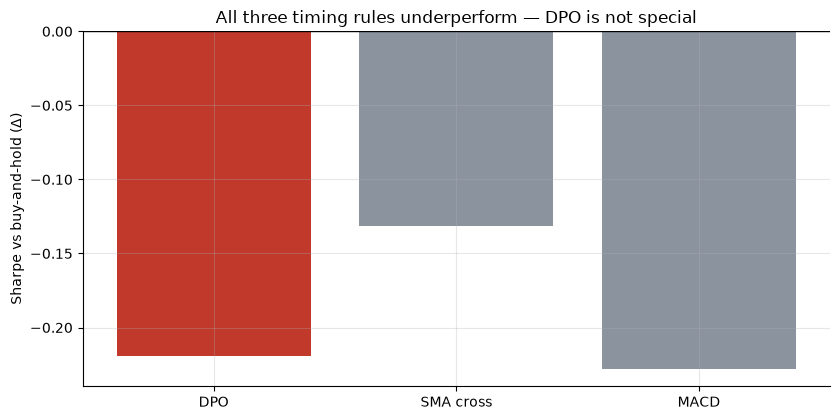

Every market-timing rule here gives up Sharpe vs holding; DPO is no exception.


In [4]:
if HAVE_REAL:
    s = st.run_experiment(data.load_real('SPY', cache_dir=CACHE, end=AS_OF)['close'],
                          period=20, band_k=1.0, cost_bps=1.0, n_perm=1)
    deltas = {'DPO': s['sharpe_delta'], 'SMA cross': s['bench']['sma']['sharpe_delta'],
              'MACD': s['bench']['macd']['sharpe_delta']}
else:
    deltas = {'DPO': -0.22, 'SMA cross': -0.13, 'MACD': -0.23}
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(list(deltas), list(deltas.values()), color=[RED, GREY, GREY])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Sharpe vs buy-and-hold (Δ)')
ax.set_title('All three timing rules underperform — DPO is not special')
plt.tight_layout(); plt.show()
print('Every market-timing rule here gives up Sharpe vs holding; DPO is no exception.')

DPO, the SMA crossover, and MACD all give up Sharpe versus buy-and-hold. DPO's promise was that detrending makes it *special* — it isn't. It is just another trend-fighting timing rule.

## 5 · The verdict

- **Signal — None.** DPO long/flat nets +0.43 Sharpe vs buy-and-hold +0.65 (-5.5%/yr). The HAC *t* = -3.11 is significant but *negative* — there is no positive cycle edge.
- **Tradability — Mirage.** A structural loser before costs on every tape; costs only deepen the loss.
- **Isolates a tradable cycle? — Busted.** The 'cycle' the DPO surfaces does not pay; the timing shuffle can't distinguish the real run from random on most tapes.

## 6 · Could you actually trade it?

At ~10 trades/yr the turnover is tiny — but it doesn't matter, because the rule loses *before* costs:

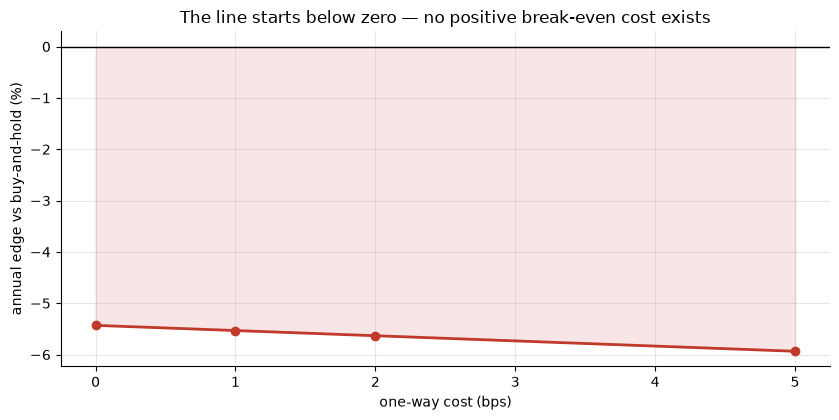

Gross edge already negative — costs are not the killer, the rule is.


In [5]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    cl = data.load_real('SPY', cache_dir=CACHE, end=AS_OF)['close']
    deltas = [st.run_experiment(cl, period=20, cost_bps=c, n_perm=1)['ann_edge']*100 for c in costs]
else:
    deltas = [-5.43, -5.53, -5.63, -5.94]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, deltas, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, deltas, 0, color=RED, alpha=.12)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('annual edge vs buy-and-hold (%)')
ax.set_title('The line starts below zero — no positive break-even cost exists')
plt.tight_layout(); plt.show()
print('Gross edge already negative — costs are not the killer, the rule is.')

## 7 · Going further

- **The positive control.** The companion notebook plants a *real* sine-wave cycle in a synthetic tape — and the DPO rule finds it cleanly (Sharpe vs hold jumps to +3.7 at a modest amplitude). The machine is correctly built; the real market simply doesn't contain a tradable cycle of that flavour.
- **The look-ahead trap.** The *textbook* DPO is drawn shifted back half a window — which means it peeks at its own future. The quants' notebook shows how that displacement inflates a naive backtest, and why our tradable version refuses to use it.
- **Cousins on the bench.** [CCI](../../178-cci/), [Bollinger reversion](../../104-bollinger-reversion/), [Williams %R](../../127-williams-r/) — the same overbought/oversold family, same honest verdict.

*Think detrending works on a different asset class or cycle length? Fork this, change the instrument or the window, and show a fair-bet edge that beats buy-and-hold and clears HAC inference. That is the bar.*